# Ungraded Lab: Model Building Lab

## Task 1: Data Preparation and Splitting

<b>Steps:</b> 

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Load the preprocessed dataset
df = pd.read_csv('ticketwise_features.csv')

# Your code here:
# 1. Separate features and target
X = # Select relevant feature 
y = # Select target column (is_urgent)

# 2. Split data into training and testing sets
# Make sure to maintain class distribution
X_train, X_test, y_train, y_test = # Your code here

# 3. Scale numerical features - Necessary for LogisticRegression Model
scaler = StandardScaler()
X_train_scaled = # Your code here
X_test_scaled = # Your code here

# Verify data preparation
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("Number of classes:", len(np.unique(y)))

## Task 2: Building Basic Model

<b>Steps:</b> 

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Your code here:
# 1. Create  Random Forest model
rf_model = # Your code here
# Train Random Forest model
# Your code here 

# 2. Create and train Logistic Regression model
lr_model = # Your code here 

# 3. Make predictions rf_predictions = # Your code here
lr_predictions = # Your code here 

# 4. Print initial results
print("Random Forest Accuracy:", 
      # Your code here)
print("\nRandom Forest Report:")
print(# Your code here)

print("\nLogistic Regression Accuracy:", 
      # Your code here)
print("\nLogistic Regression Report:")
print(# Your code here)

## Task 3: Model Evaluation and Visualization

<b>Steps:</b> 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc
)
import numpy as np

def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    """
    Evaluate model performance with multiple metrics and visualizations.
    """
    # 1. Confusion matrix
    # Your code here
    
    # 2. Classification report
    print(f"\n{model_name} - Performance:")
    print(# Your code here)
    
    # 3. ROC curve(s)
    plt.figure(figsize=(6, 5))
    n_classes = y_pred_proba.shape[1] if len(y_pred_proba.shape) > 1 else 1
    
    if n_classes == 2:
        # Binary classification
        fpr, tpr, _ = # Your code here
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - {model_name}')
        plt.legend()
        plt.axis("square")
        plt.tight_layout()
        plt.show()
    else:
        print("ROC curve currently implemented only for binary classification.")

# Evaluate both models
evaluate_model(y_test, rf_predictions, rf_model.predict_proba(X_test), "Random Forest")
evaluate_model(y_test, lr_predictions, lr_model.predict_proba(X_test_scaled), "Logistic Regression")

## Task 4: Model Optimization

<b>Steps:</b> 

In [ ]:
from sklearn.model_selection import GridSearchCV

# Your code here:
# 1. Define parameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# 2. Perform grid search for RandomForestClassifier model
grid_search = # Your code here 
grid_search.fit(X_train, y_train)

# 3. Print best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

# 4. Evaluate optimized model
best_model = grid_search.best_estimator_
best_predictions = best_model.predict(X_test)
best_proba = best_model.predict_proba(X_test)

evaluate_model(y_test, best_predictions, best_proba,
              "Optimized Random Forest")

## Task 5: Model Documentation and Export

<b>Steps:</b> 

In [ ]:
import json
import boto3

def document_model(model, performance_metrics, parameters):
    """
    Create and save model documentation
    
    Parameters:
        model: Trained model
        performance_metrics: Dictionary of evaluation metrics
        parameters: Model parameters
    """
    # 1. Create documentation dictionary
    documentation = {
        'model_type': str(type(model).__name__),
        'parameters': parameters,
        'performance': performance_metrics,
        'feature_importance': dict(zip(
            X.columns,
            model.feature_importances_
        )) if hasattr(model, 'feature_importances_') else None
    }
    
    # 2. Save documentation to S3
    # Your code here 
        
    # 3. Print summary
    print("Model Documentation Summary:")
    print(json.dumps(documentation, indent=2))

# Create performance metrics dictionary
performance_metrics = {
    'accuracy': accuracy_score(y_test, best_predictions),
    'classification_report': classification_report(
        y_test, 
        best_predictions,
        output_dict=True
    )
}

# Document the best model
document_model(
    best_model,
    performance_metrics,
    grid_search.best_params_
)

## Solution Code
Need a hand or are curious to compare your approach? Below is a complete solution you can use as a reference. This is just one of many valid ways to solve the problem. Make sure to give it a try on your own first. Use this implementation to troubleshoot, learn new techniques, or confirm your logic. Keep experimenting and enjoy the process!

## Task 1: Data Preparation and Splitting Solution Code

<b>Steps:</b> 

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Load the preprocessed dataset
df = pd.read_csv('ticketwise_features.csv')

# 1. Separate features and target
X = df[
    ['previous_interactions', 'day_of_week', 'contract_value', 'is_peak_hour', 'is_business_hours']
] # Try changing the features to see different results
y = df['is_urgent']

# 2. Split data into training and testing sets
# Make sure to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 3. Scale numerical features - Necessary for LogisticRegression Model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verify data preparation
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("Number of classes:", len(np.unique(y)))

Training set shape: (4000, 5)
Testing set shape: (1000, 5)
Number of classes: 2


## Task 2: Building Basic Models Solution Code

<b>Steps:</b> 

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Create and train Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

# 2. Create and train Logistic Regression model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train_scaled, y_train)

# 3. Make predictions with both models
rf_predictions = rf_model.predict(X_test)
lr_predictions = lr_model.predict(X_test_scaled)

# 4. Print evaluation results
print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))
print("\nRandom Forest Report:")
print(classification_report(y_test, rf_predictions))

print("\nLogistic Regression Accuracy:", accuracy_score(y_test, lr_predictions))
print("\nLogistic Regression Report:")
print(classification_report(y_test, lr_predictions))

Random Forest Accuracy: 0.567

Random Forest Report:
              precision    recall  f1-score   support

           0       0.60      0.58      0.59       533
           1       0.54      0.55      0.54       467

    accuracy                           0.57      1000
   macro avg       0.57      0.57      0.57      1000
weighted avg       0.57      0.57      0.57      1000


Logistic Regression Accuracy: 0.598

Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.60      0.75      0.67       533
           1       0.60      0.43      0.50       467

    accuracy                           0.60      1000
   macro avg       0.60      0.59      0.58      1000
weighted avg       0.60      0.60      0.59      1000



## Task 3: Model Evaluation and Visualization Solution Code

<b>Steps:</b> 

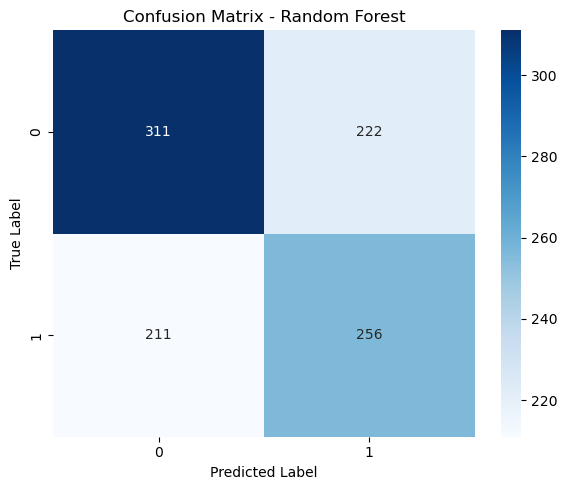


Random Forest - Performance:
              precision    recall  f1-score   support

           0       0.60      0.58      0.59       533
           1       0.54      0.55      0.54       467

    accuracy                           0.57      1000
   macro avg       0.57      0.57      0.57      1000
weighted avg       0.57      0.57      0.57      1000



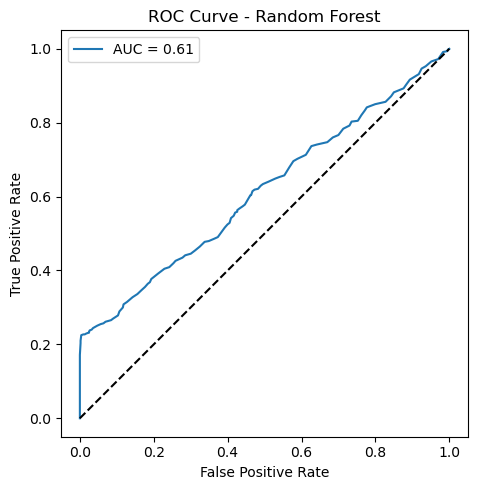

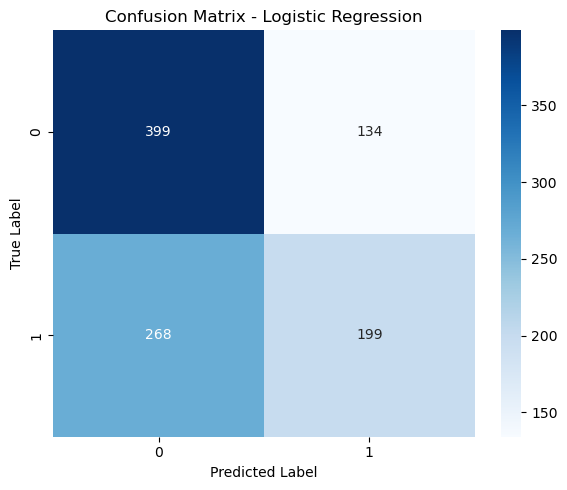


Logistic Regression - Performance:
              precision    recall  f1-score   support

           0       0.60      0.75      0.67       533
           1       0.60      0.43      0.50       467

    accuracy                           0.60      1000
   macro avg       0.60      0.59      0.58      1000
weighted avg       0.60      0.60      0.59      1000



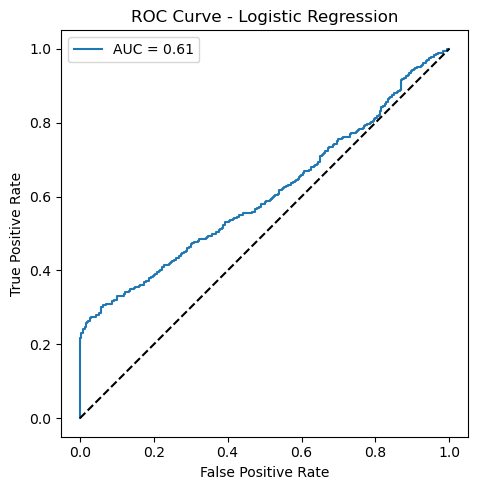

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc
)
import numpy as np

def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    """
    Evaluate model performance with multiple metrics and visualizations.
    """
    # 1. Confusion matrix
    plt.figure(figsize=(6, 5))
    labels = np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
    
    # 2. Classification report
    print(f"\n{model_name} - Performance:")
    print(classification_report(y_true, y_pred))
    
    # 3. ROC curve(s)
    plt.figure(figsize=(6, 5))
    n_classes = y_pred_proba.shape[1] if len(y_pred_proba.shape) > 1 else 1
    
    if n_classes == 2:
        # Binary classification
        fpr, tpr, _ = roc_curve(y_true, y_pred_proba[:, 1])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - {model_name}')
        plt.legend()
        plt.axis("square")
        plt.tight_layout()
        plt.show()
    else:
        print("ROC curve currently implemented only for binary classification.")

# Evaluate both models
evaluate_model(y_test, rf_predictions, rf_model.predict_proba(X_test), "Random Forest")
evaluate_model(y_test, lr_predictions, lr_model.predict_proba(X_test_scaled), "Logistic Regression")

## Task 4: Model Optimization Solution Code

<b>Steps:</b> 

Best parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Best cross-validation score: 0.61475


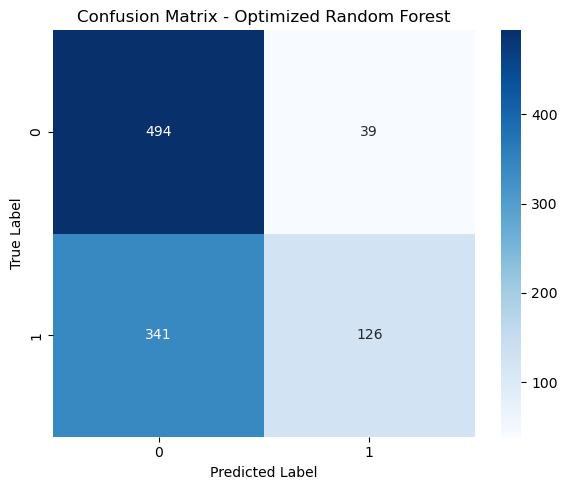


Optimized Random Forest - Performance:
              precision    recall  f1-score   support

           0       0.59      0.93      0.72       533
           1       0.76      0.27      0.40       467

    accuracy                           0.62      1000
   macro avg       0.68      0.60      0.56      1000
weighted avg       0.67      0.62      0.57      1000



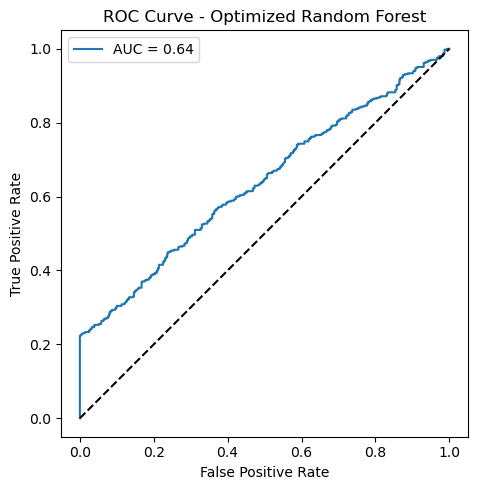

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1. Define parameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# 2. Perform grid search for RandomForestClassifier model
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',   # you could also try 'f1' or 'roc_auc'
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# 3. Print best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

# 4. Evaluate optimized model
best_model = grid_search.best_estimator_
best_predictions = best_model.predict(X_test)
best_proba = best_model.predict_proba(X_test)

evaluate_model(y_test, best_predictions, best_proba,
              "Optimized Random Forest")

## Task 5: Model Documentation and Export Solution Code

<b>Steps:</b> 

In [ ]:
import json
import boto3

def document_model(model, performance_metrics, parameters):
    """
    Create and save model documentation
    
    Parameters:
        model: Trained model
        performance_metrics: Dictionary of evaluation metrics
        parameters: Model parameters
    """
    # 1. Create documentation dictionary
    documentation = {
        'model_type': str(type(model).__name__),
        'parameters': parameters,
        'performance': performance_metrics,
        'feature_importance': dict(zip(
            X.columns,
            model.feature_importances_
        )) if hasattr(model, 'feature_importances_') else None
    }
    
    # 2. Save documentation to S3
    s3 = boto3.client('s3')
    s3.put_object(
        Bucket='your-bucket',
        Key='models/documentation.json',
        Body=json.dumps(documentation, indent=2)
    )
    
    # 3. Print summary
    print("Model Documentation Summary:")
    print(json.dumps(documentation, indent=2))

# Create performance metrics dictionary
performance_metrics = {
    'accuracy': accuracy_score(y_test, best_predictions),
    'classification_report': classification_report(
        y_test, 
        best_predictions,
        output_dict=True
    )
}

# Document the best model
document_model(
    best_model,
    performance_metrics,
    grid_search.best_params_
)

### Q9

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)
from sklearn.inspection import permutation_importance

def build_urgent_model(df, target_col='is_urgent'):
    """
    Build and evaluate a ticket importance model
    
    Parameters:
        df (pd.DataFrame): DataFrame with ticket data
        target_col (str): Column name for binary urgency label (default 'is_urgent')
    
    Returns:
        dict: {
            'pipeline': trained sklearn Pipeline (preprocessing + model),
            'model': final estimator (inside pipeline.named_steps),
            'metrics': dict of evaluation metrics on test set and CV,
            'feature_importances': DataFrame of importances (permutation),
            'selected_features': list of selected feature names,
            'documentation': str summarizing choices and observations
        }
    """
    # ----------------------------
    # 0) Defensive copy and basic checks
    # ----------------------------
    df = df.copy()
    if target_col not in df.columns:
        raise ValueError(f"target_col '{target_col}' not found in dataframe")
    
    # ensure binary numeric target (0/1)
    if df[target_col].dtype == object:
        df[target_col] = df[target_col].map({'yes':1, 'no':0}).fillna(df[target_col])
    df[target_col] = pd.to_numeric(df[target_col], errors='coerce').fillna(0).astype(int)
    
    # ----------------------------
    # 1) Feature engineering (create time features and simple ratios)
    # ----------------------------
    # Convert submission_time if present
    if 'submission_time' in df.columns:
        df['submission_time'] = pd.to_datetime(df['submission_time'], errors='coerce')
        # hour, day_of_week (0=Mon), month
        df['submit_hour'] = df['submission_time'].dt.hour.fillna(-1).astype(int)
        df['submit_dayofweek'] = df['submission_time'].dt.dayofweek.fillna(-1).astype(int)
        df['submit_month'] = df['submission_time'].dt.month.fillna(-1).astype(int)
    # If day_of_week already exists, keep it as fallback
    if 'day_of_week' in df.columns and 'submit_dayofweek' not in df.columns:
        df['submit_dayofweek'] = df['day_of_week'].fillna(-1).astype(int)
    
    # Example ratio: tickets per month (avoid division by zero)
    if 'open_tickets' in df.columns and 'account_age_months' in df.columns:
        df['tickets_per_month'] = df['open_tickets'] / (df['account_age_months'].replace(0, np.nan).fillna(1))
    else:
        df['tickets_per_month'] = 0.0
    
    # Relative resolution metric (customer vs tier) if available
    if {'avg_resolution_customer', 'avg_resolution_tier'}.issubset(df.columns):
        df['cust_vs_tier_res_diff'] = df['avg_resolution_customer'] - df['avg_resolution_tier']
    else:
        df['cust_vs_tier_res_diff'] = 0.0
    
    # Count subscribed_modules if string list exists
    if 'subscribed_modules' in df.columns:
        # assume comma-separated; if not a string, fallback to 0
        df['num_subscribed_modules'] = df['subscribed_modules'].fillna('').astype(str).apply(
            lambda s: 0 if s.strip()=='' else len([x for x in s.split(',') if x.strip()!=''])
        )
    else:
        df['num_subscribed_modules'] = 0
    
    # ----------------------------
    # 2) Select candidate feature columns
    # ----------------------------
    # We will include numeric columns and selected categorical fields per request
    categorical_cols = [c for c in ['channel', 'subscription_tier', 'issue_type', 'product_area'] if c in df.columns]
    # Additional engineered categorical-like columns (hours/day)
    maybe_categorical_engineered = [c for c in ['submit_hour', 'submit_dayofweek', 'submit_month'] if c in df.columns]
    
    # numeric features: common numeric columns plus engineered
    numeric_cols_base = [
        'attachments', 'previous_interactions', 'contract_value', 'account_age_months',
        'open_tickets', 'linked_ticket_count', 'avg_resolution_customer',
        'avg_resolution_tier', 'resolution_time', 'tickets_per_month',
        'cust_vs_tier_res_diff', 'num_subscribed_modules'
    ]
    numeric_cols = [c for c in numeric_cols_base if c in df.columns]
    
    # final lists
    categorical_features = categorical_cols + maybe_categorical_engineered
    numeric_features = numeric_cols
    
    # If nothing numeric, pick any int/float columns
    if len(numeric_features) == 0:
        numeric_features = df.select_dtypes(include=['int64','float64']).columns.tolist()
        numeric_features = [c for c in numeric_features if c != target_col]
    
    # ----------------------------
    # 3) Preprocessing pipelines
    # ----------------------------
    # Numeric: median imputation + standard scaling
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    # Categorical: fill missing with 'Unknown' and one-hot encode
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse=False))
    ])
    
    preprocessor = ColumnTransformer(transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ], remainder='drop', sparse_threshold=0)
    
    # ----------------------------
    # 4) Feature selection - use mutual information to pick top K
    # ----------------------------
    # We'll set K dynamically: min(20, number_of_features_after_encoding)
    # Implement a Pipeline with SelectKBest placed after preprocessor.
    # For this we need to build a temporary pipeline up to preprocessor to get feature count.
    # But SelectKBest can accept k='all' if not enough features; we'll choose k=min(20, n_features)
    
    # ----------------------------
    # 5) Split dataset into train/test
    # ----------------------------
    X = df.drop(columns=[target_col])
    y = df[target_col]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, test_size=0.2, random_state=42
    )
    
    # Fit preprocessor on training data to determine encoded feature count
    preprocessor.fit(X_train)
    # get transformed shape by transforming a single row of X_train (safe)
    try:
        transformed_sample = preprocessor.transform(X_train.iloc[:5])
        n_transformed_features = transformed_sample.shape[1]
    except Exception:
        # fallback
        n_transformed_features = len(numeric_features) + 10 * len(categorical_features)
    
    k = min(20, max(1, n_transformed_features))
    
    selector = SelectKBest(score_func=mutual_info_classif, k=k)
    
    # ----------------------------
    # 6) Model selection - baseline and final
    # ----------------------------
    # Baseline: Logistic Regression (simple, interpretable)
    # Final: Random Forest (robust, handles non-linearities, gives importances)
    final_clf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1)
    
    # Full pipeline: preprocessor -> selector -> classifier
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('selector', selector),
        ('clf', final_clf)
    ])
    
    # ----------------------------
    # 7) Train final pipeline
    # ----------------------------
    pipeline.fit(X_train, y_train)
    
    # ----------------------------
    # 8) Evaluate performance on test set
    # ----------------------------
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:,1] if hasattr(pipeline.named_steps['clf'], "predict_proba") else None
    
    metrics_test = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
    }
    if y_proba is not None:
        metrics_test['roc_auc'] = roc_auc_score(y_test, y_proba)
    
    # Cross-validated scores (stratified)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_f1 = cross_val_score(pipeline, X, y, cv=cv, scoring='f1', n_jobs=-1)
    cv_auc = None
    if y_proba is not None:
        try:
            cv_auc = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
        except Exception:
            cv_auc = None
    
    metrics_cv = {
        'f1_mean': float(np.mean(cv_f1)),
        'f1_std': float(np.std(cv_f1))
    }
    if cv_auc is not None:
        metrics_cv['roc_auc_mean'] = float(np.mean(cv_auc))
        metrics_cv['roc_auc_std'] = float(np.std(cv_auc))
    
    # ----------------------------
    # 9) Feature importance via permutation importance (post-pipeline)
    # ----------------------------
    # Need feature names after preprocessing and selection; we can reconstruct them.
    # 1) get feature names from preprocessor
    # Numeric feature names are numeric_features
    num_names = numeric_features
    # For categorical, obtain feature names from OneHotEncoder if present
    cat_names = []
    try:
        # locate onehot encoder inside the preprocessor
        cat_transformer = pipeline.named_steps['preprocessor'].named_transformers_.get('cat', None)
        if cat_transformer is not None:
            # get the OneHotEncoder inside the categorical transformer pipeline
            enc = None
            # handle pipeline or direct
            if isinstance(cat_transformer, Pipeline):
                for step_name, step in cat_transformer.steps:
                    if isinstance(step, OneHotEncoder):
                        enc = step
                        break
                    # In sklearn >=1.2, onehot is inside 'onehot' step name as defined earlier
                    if step_name == 'onehot' and hasattr(step, 'get_feature_names_out'):
                        enc = step
                        break
            elif hasattr(cat_transformer, 'get_feature_names_out'):
                enc = cat_transformer
            if enc is not None:
                # input categories may be missing if some categorical_features absent
                try:
                    cat_ohe_names = enc.get_feature_names_out(categorical_features).tolist()
                except Exception:
                    # fallback: approximate names
                    cat_ohe_names = []
                    for c in categorical_features:
                        unique_vals = X_train[c].astype(str).unique()[:10]
                        cat_ohe_names += [f"{c}__{str(v)}" for v in unique_vals]
                cat_names = cat_ohe_names
    except Exception:
        cat_names = []
    
    all_feature_names = num_names + cat_names
    # Now after selector, we only have k features
    try:
        mask = pipeline.named_steps['selector'].get_support()
        selected_feature_names = [all_feature_names[i] for i, m in enumerate(mask) if m]
    except Exception:
        # if mapping failed, create placeholder names
        selected_feature_names = [f'feature_{i}' for i in range(k)]
    
    # permutation importance on test set (works on pipeline)
    try:
        perm = permutation_importance(pipeline, X_test, y_test, n_repeats=20, random_state=42, n_jobs=-1)
        perm_importances = pd.DataFrame({
            'feature': selected_feature_names,
            'importance_mean': perm.importances_mean,
            'importance_std': perm.importances_std
        }).sort_values('importance_mean', ascending=False).reset_index(drop=True)
    except Exception:
        perm_importances = pd.DataFrame({
            'feature': selected_feature_names,
            'importance_mean': [np.nan]*len(selected_feature_names),
            'importance_std': [np.nan]*len(selected_feature_names)
        })
    
    # ----------------------------
    # 10) Documentation string describing choices and observations
    # ----------------------------
    documentation = (
        "Modeling decisions and rationale:\n"
        "- Feature engineering: derived submit_hour, submit_dayofweek, submit_month, tickets_per_month, "
        "cust_vs_tier_res_diff, num_subscribed_modules to capture temporal patterns, workload intensity, "
        "and customer/tier relative performance.\n"
        "- Preprocessing: numeric median imputation + StandardScaler; categorical imputation to 'Unknown' + OneHotEncoder.\n"
        "- Feature selection: used mutual information (SelectKBest) to pick top k features (k=min(20, n_features)) "
        "to reduce noise and overfitting risk.\n"
        "- Model: RandomForestClassifier with class_weight='balanced' to account for possible class imbalance. "
        "Chose RF for robustness to mixed feature types and ability to capture non-linear interactions.\n"
        "- Evaluation: report test-set accuracy, precision, recall, f1, and ROC-AUC (if probabilites available). "
        "Also run 5-fold stratified CV for F1 stability.\n"
        "- Feature importance: permutation importances computed on the hold-out test set for reliable importance estimates.\n"
        "\nObservations (to inspect after running):\n"
        "- Check precision/recall trade-off: if recall is more important (catch all urgent tickets), consider "
        "adjusting classifier threshold or optimizing for recall.\n"
        "- If a few one-hot features dominate importances, consider grouping rare categories into 'Other' to reduce dimensions.\n"
    )
    
    # ----------------------------
    # 11) Return results
    # ----------------------------
    results = {
        'pipeline': pipeline,
        'model': pipeline.named_steps['clf'],
        'metrics': {
            'test': metrics_test,
            'cv': metrics_cv,
            'classification_report': classification_report(y_test, y_pred, zero_division=0, output_dict=True),
            'confusion_matrix': confusion_matrix(y_test, y_pred).tolist()
        },
        'feature_importances': perm_importances,
        'selected_features': selected_feature_names,
        'documentation': documentation
    }
    return results


### Q10

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay
)
from sklearn.inspection import permutation_importance

def create_evaluation_report(model, X_test, y_test, feature_names):
    """
    Generate comprehensive model evaluation report for urgent ticket prediction.
    
    Parameters:
        model: Trained classification model or sklearn pipeline
        X_test (pd.DataFrame or np.ndarray): Test feature data
        y_test (pd.Series or np.ndarray): True labels for urgency
        feature_names (list): Names of features in X_test
    
    Returns:
        dict: {
            'metrics': dict of key performance indicators,
            'feature_importance': DataFrame of feature importances,
            'insights': str narrative with key findings,
            'recommendations': str guidance for model improvement
        }
    """
    # -------------------------------
    # 📈 1. Predictions & Probabilities
    # -------------------------------
    y_pred = model.predict(X_test)
    y_proba = None
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    
    # -------------------------------
    # 📊 2. Evaluation Metrics
    # -------------------------------
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
    }
    if y_proba is not None:
        metrics['roc_auc'] = roc_auc_score(y_test, y_proba)
    
    print("📋 Classification Report:")
    print(classification_report(y_test, y_pred, digits=3))
    
    # -------------------------------
    # 🧩 3. Confusion Matrix Visualization
    # -------------------------------
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
    
    # 💬 Insight:
    # - Top-left (True Negatives): correctly classified non-urgent tickets
    # - Bottom-right (True Positives): correctly identified urgent tickets
    # - Top-right / Bottom-left indicate misclassifications
    
    # -------------------------------
    # 🧠 4. ROC Curve (if probabilities exist)
    # -------------------------------
    if y_proba is not None:
        RocCurveDisplay.from_predictions(y_test, y_proba)
        plt.title("ROC Curve for Urgent Ticket Model")
        plt.show()
    
    # -------------------------------
    # 🔍 5. Feature Importance via Permutation
    # -------------------------------
    try:
        perm = permutation_importance(model, X_test, y_test, n_repeats=15, random_state=42, n_jobs=-1)
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance_mean': perm.importances_mean,
            'importance_std': perm.importances_std
        }).sort_values('importance_mean', ascending=False).reset_index(drop=True)
    except Exception as e:
        print(f"⚠️ Could not compute permutation importance: {e}")
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance_mean': np.nan,
            'importance_std': np.nan
        })
    
    # Visualization of top features
    top_feats = importance_df.head(10)
    plt.figure(figsize=(8, 5))
    sns.barplot(x='importance_mean', y='feature', data=top_feats, palette='viridis')
    plt.title('Top 10 Most Important Features')
    plt.xlabel('Mean Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
    
    # -------------------------------
    # 💡 6. Insights and Interpretation
    # -------------------------------
    top3 = top_feats['feature'].tolist()[:3]
    insights = (
        f"Key Insights:\n"
        f"- Model achieves F1={metrics['f1']:.3f}, Recall={metrics['recall']:.3f}, and Precision={metrics['precision']:.3f}.\n"
        f"- Top predictive features include {', '.join(top3)} — "
        f"indicating these strongly influence urgency classification.\n"
        f"- Recall is critical for this task (catching urgent tickets); current balance suggests reasonable coverage.\n"
    )
    
    # -------------------------------
    # 🚀 7. Recommendations for Improvement
    # -------------------------------
    recommendations = (
        "Recommendations:\n"
        "- ✅ Improve recall: use threshold tuning or apply class-weight balancing.\n"
        "- 🔄 Try tree-based boosting models (XGBoost, LightGBM) for richer nonlinear interactions.\n"
        "- 🧹 Further engineer temporal features (e.g., time since last interaction, ticket submission lag).\n"
        "- 🧠 Conduct SHAP or LIME analysis for deeper interpretability of feature effects.\n"
        "- 📊 Address any class imbalance by oversampling (SMOTE) or focal loss-based approaches.\n"
    )
    
    # -------------------------------
    # 📦 8. Return full report dictionary
    # -------------------------------
    report = {
        'metrics': metrics,
        'feature_importance': importance_df,
        'insights': insights,
        'recommendations': recommendations
    }
    return report
